In [8]:
# === CELL 1: Setup (your existing code) ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ... your data load, split, preprocessor, pipeline.fit ...
# === CELL 1: Setup ===
import os

# Create output directories if they don't exist
os.makedirs('../reports/figures', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# ... rest of your imports and code

In [11]:
# === CELL 2: Coefficients ===
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
coefficients = pipeline.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

print(coef_df.head(15).to_string(index=False))

                            Feature  Coefficient  Abs_Coefficient
             cat__Contract_Two year    -1.445120         1.445120
                        num__tenure    -1.258362         1.258362
   cat__InternetService_Fiber optic     1.125391         1.125391
             cat__Contract_One year    -0.785572         0.785572
                  num__TotalCharges     0.610057         0.610057
                num__MonthlyCharges    -0.476384         0.476384
cat__PaymentMethod_Electronic check     0.418495         0.418495
               cat__StreamingTV_Yes     0.382479         0.382479
              cat__PhoneService_Yes    -0.374183         0.374183
           cat__StreamingMovies_Yes     0.367871         0.367871
            cat__OnlineSecurity_Yes    -0.350809         0.350809
             cat__MultipleLines_Yes     0.335754         0.335754
               cat__TechSupport_Yes    -0.309642         0.309642
          cat__PaperlessBilling_Yes     0.258044         0.258044
          

/tmp/ipykernel_2757/785960755.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=top_15, palette=colors)


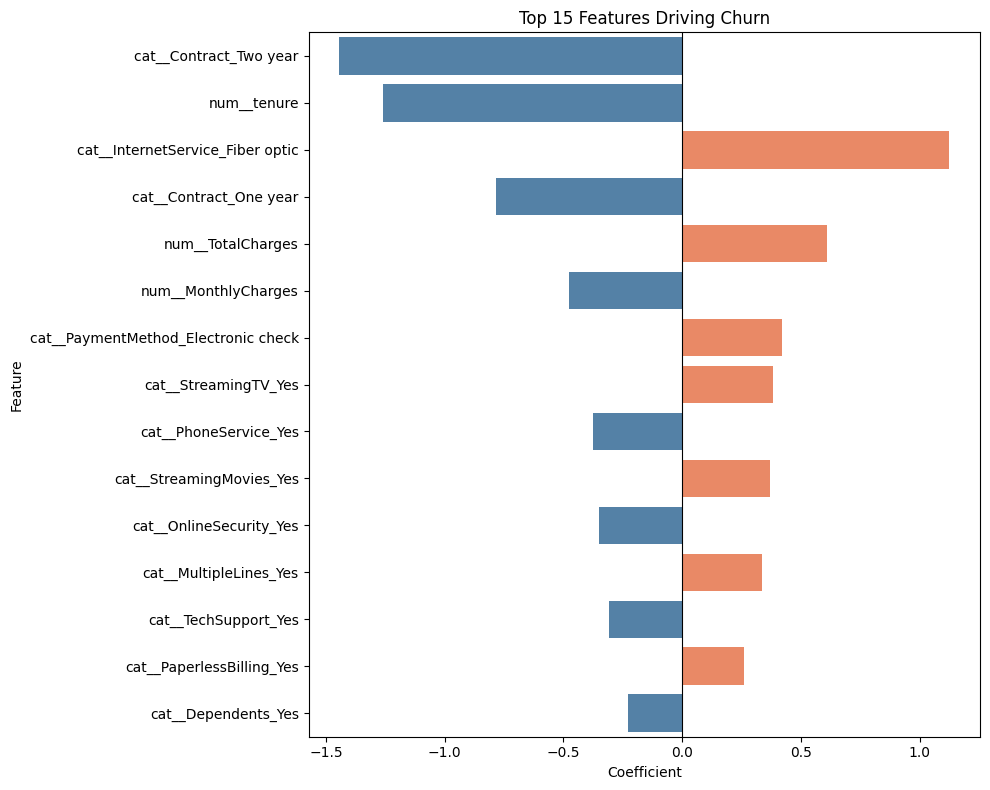

In [12]:
# === CELL 3: Coefficient plot ===
plt.figure(figsize=(10, 8))
top_15 = coef_df.head(15)
colors = ['coral' if c > 0 else 'steelblue' for c in top_15['Coefficient']]
sns.barplot(x='Coefficient', y='Feature', data=top_15, palette=colors)
plt.title('Top 15 Features Driving Churn')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../reports/figures/phase4_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# === CELL 4: Push/pull factors ===
push_factors = coef_df[coef_df['Coefficient'] > 0].head(10)
pull_factors = coef_df[coef_df['Coefficient'] < 0].head(10)

print("🔴 PUSH FACTORS (increase churn risk):")
for _, row in push_factors.iterrows():
    print(f"  • {row['Feature']}: +{row['Coefficient']:.3f}")

print("\n🟢 PULL FACTORS (decrease churn risk):")
for _, row in pull_factors.iterrows():
    print(f"  • {row['Feature']}: {row['Coefficient']:.3f}")

🔴 PUSH FACTORS (increase churn risk):
  • cat__InternetService_Fiber optic: +1.125
  • num__TotalCharges: +0.610
  • cat__PaymentMethod_Electronic check: +0.418
  • cat__StreamingTV_Yes: +0.382
  • cat__StreamingMovies_Yes: +0.368
  • cat__MultipleLines_Yes: +0.336
  • cat__PaperlessBilling_Yes: +0.258
  • cat__PaymentMethod_Credit card (automatic): +0.080
  • num__SeniorCitizen: +0.076
  • cat__DeviceProtection_Yes: +0.070

🟢 PULL FACTORS (decrease churn risk):
  • cat__Contract_Two year: -1.445
  • num__tenure: -1.258
  • cat__Contract_One year: -0.786
  • num__MonthlyCharges: -0.476
  • cat__PhoneService_Yes: -0.374
  • cat__OnlineSecurity_Yes: -0.351
  • cat__TechSupport_Yes: -0.310
  • cat__Dependents_Yes: -0.227
  • cat__StreamingMovies_No internet service: -0.170
  • cat__DeviceProtection_No internet service: -0.170


In [14]:
# === CELL 5: SHAP setup ===
X_test_transformed = pipeline.named_steps['preprocessor'].transform(X_test)

explainer = shap.LinearExplainer(
    pipeline.named_steps['classifier'],
    X_test_transformed,
    feature_names=feature_names
)

shap_values = explainer(X_test_transformed)
print("SHAP values computed")

SHAP values computed


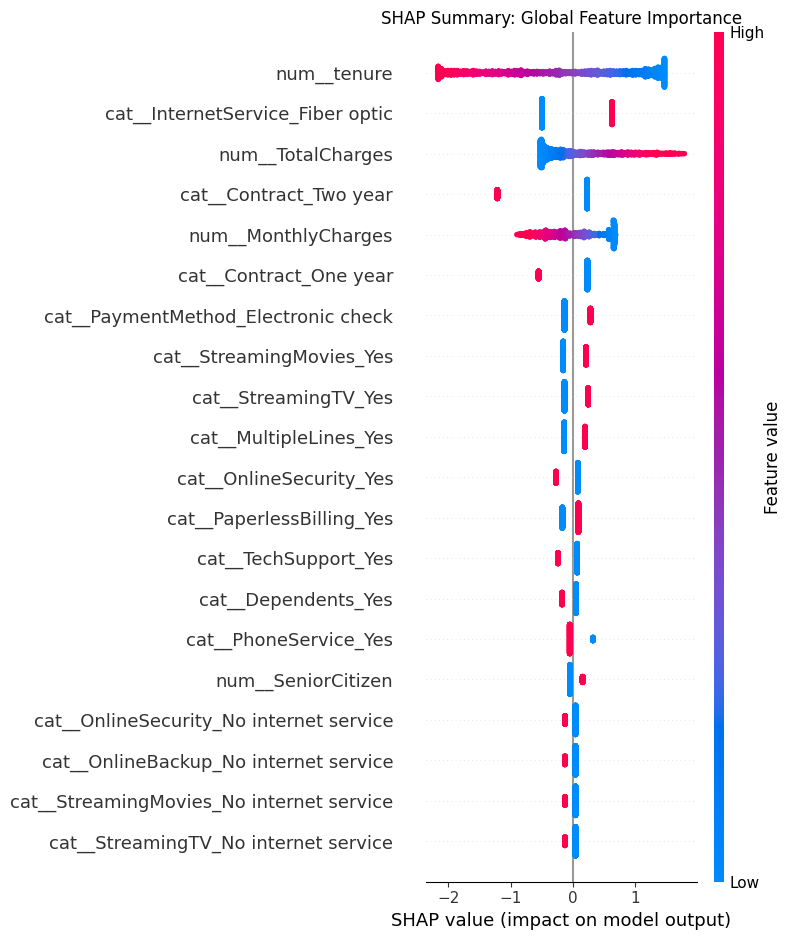

In [15]:
# === CELL 6: SHAP summary plot ===
plt.figure()
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, show=False)
plt.title('SHAP Summary: Global Feature Importance')
plt.tight_layout()
plt.savefig('../reports/figures/phase4_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

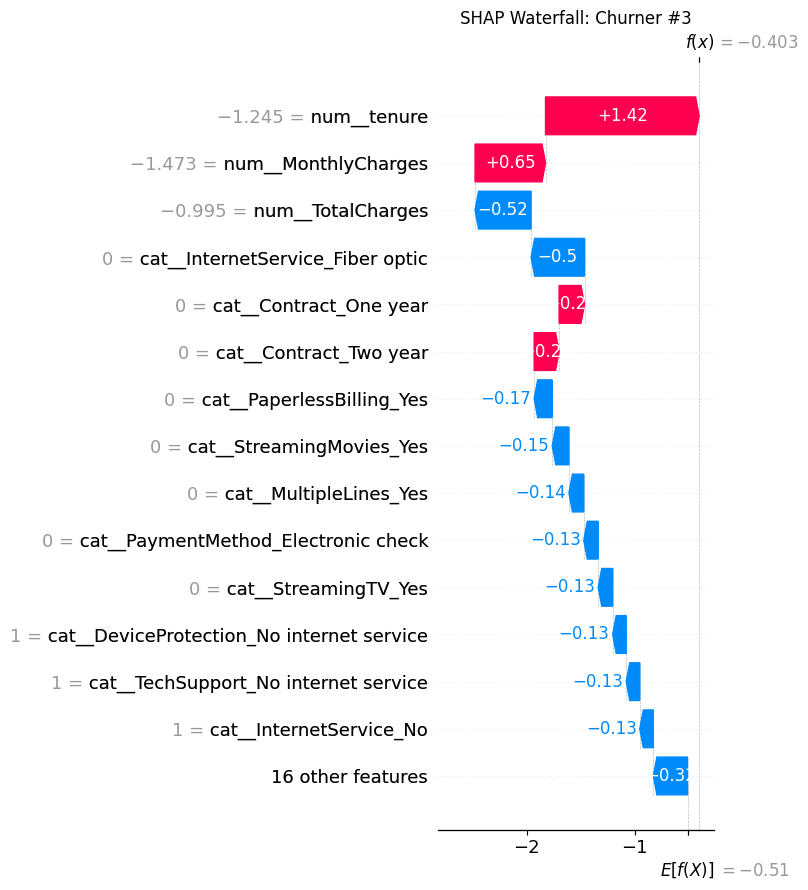

In [16]:
# === CELL 7: Waterfall — churner ===
churner_idx = y_test.reset_index(drop=True)[y_test.reset_index(drop=True) == 1].index[0]

plt.figure()
shap.waterfall_plot(shap_values[churner_idx], max_display=15, show=False)
plt.title(f'SHAP Waterfall: Churner #{churner_idx}')
plt.tight_layout()
plt.savefig(f'../reports/figures/phase4_waterfall_churner_{churner_idx}.png', dpi=150, bbox_inches='tight')
plt.show()

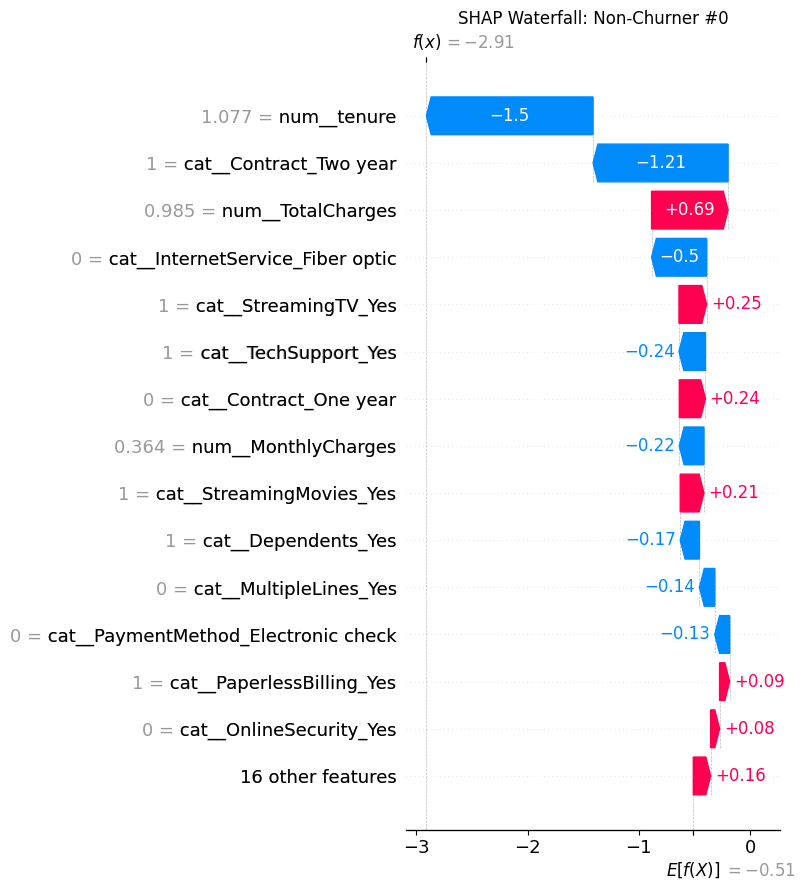

In [17]:
# === CELL 8: Waterfall — stayer ===
stayer_idx = y_test.reset_index(drop=True)[y_test.reset_index(drop=True) == 0].index[0]

plt.figure()
shap.waterfall_plot(shap_values[stayer_idx], max_display=15, show=False)
plt.title(f'SHAP Waterfall: Non-Churner #{stayer_idx}')
plt.tight_layout()
plt.savefig(f'../reports/figures/phase4_waterfall_stayer_{stayer_idx}.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
print("Raw feature names:")
for i, name in enumerate(feature_names):
    print(f"  {i}: {name}")

Raw feature names:
  0: num__tenure
  1: num__MonthlyCharges
  2: num__TotalCharges
  3: num__SeniorCitizen
  4: cat__gender_Male
  5: cat__Partner_Yes
  6: cat__Dependents_Yes
  7: cat__PhoneService_Yes
  8: cat__MultipleLines_No phone service
  9: cat__MultipleLines_Yes
  10: cat__InternetService_Fiber optic
  11: cat__InternetService_No
  12: cat__OnlineSecurity_No internet service
  13: cat__OnlineSecurity_Yes
  14: cat__OnlineBackup_No internet service
  15: cat__OnlineBackup_Yes
  16: cat__DeviceProtection_No internet service
  17: cat__DeviceProtection_Yes
  18: cat__TechSupport_No internet service
  19: cat__TechSupport_Yes
  20: cat__StreamingTV_No internet service
  21: cat__StreamingTV_Yes
  22: cat__StreamingMovies_No internet service
  23: cat__StreamingMovies_Yes
  24: cat__Contract_One year
  25: cat__Contract_Two year
  26: cat__PaperlessBilling_Yes
  27: cat__PaymentMethod_Credit card (automatic)
  28: cat__PaymentMethod_Electronic check
  29: cat__PaymentMethod_Mailed

In [25]:
# === FIX: Re-clean names and rebuild SHAP explainer ===

# 1. Clean feature names
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
feature_names = [f.replace('num__', '').replace('cat__', '') for f in feature_names]
print("Cleaned:", feature_names[:5])

# 2. Re-create explainer with cleaned names
explainer = shap.LinearExplainer(
    pipeline.named_steps['classifier'],
    X_test_transformed,
    feature_names=feature_names
)

# 3. Re-compute SHAP values
shap_values = explainer(X_test_transformed)
print("SHAP values recomputed with clean names")

Cleaned: ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'gender_Male']
SHAP values recomputed with clean names


In [27]:
# === CELL 10: Save Model for Phase 5 ===

import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(pipeline, '../models/phase4_logistic_regression.pkl')
print("Model saved to ../models/phase4_logistic_regression.pkl")

Model saved to ../models/phase4_logistic_regression.pkl


In [28]:
# === CELL 11 (Optional): Business Rules Extraction ===

# Get predictions and probabilities on test set
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

# Build results dataframe with original features
results_df = X_test.copy()
results_df['actual_churn'] = y_test.values
results_df['predicted_churn'] = y_pred
results_df['churn_probability'] = y_proba

# High-risk segment: low tenure + month-to-month + fiber
high_risk = results_df[
    (results_df['tenure'] <= 12) & 
    (results_df['Contract'] == 'Month-to-month') &
    (results_df['InternetService'] == 'Fiber optic')
]

print(f"High-risk segment: {len(high_risk)} customers")
print(f"Actual churn rate: {high_risk['actual_churn'].mean():.1%}")
print(f"Avg predicted probability: {high_risk['churn_probability'].mean():.1%}")
print(f"\nOverall churn rate: {results_df['actual_churn'].mean():.1%}")

High-risk segment: 187 customers
Actual churn rate: 67.4%
Avg predicted probability: 83.6%

Overall churn rate: 26.6%


In [29]:
# Medium-risk: low tenure + month-to-month (any internet)
medium_risk = results_df[
    (results_df['tenure'] <= 12) & 
    (results_df['Contract'] == 'Month-to-month')
]

print(f"Medium-risk: {len(medium_risk)} customers")
print(f"Actual churn rate: {medium_risk['actual_churn'].mean():.1%}")


Medium-risk: 420 customers
Actual churn rate: 48.8%
